<a href="https://colab.research.google.com/github/D-LukeSherman/ECGR-4105/blob/main/Homework1/Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [104]:
# Use the URL for the raw CSV data
url = 'https://raw.githubusercontent.com/HamedTabkhi/Intro-to-ML/refs/heads/main/Dataset/D3.csv'

df = pd.read_csv(url)

In [105]:
from IPython.display import display
display(df)

,X1,X2,X3,Y
0,0.000000,3.440000,0.440000,4.387545
1,0.040404,0.134949,0.888485,2.679650
2,0.080808,0.829899,1.336970,2.968490
3,0.121212,1.524848,1.785455,3.254065
4,0.161616,2.219798,2.233939,3.536375
...,...,...,...,...
95,3.838384,1.460202,3.046061,-4.440595
96,3.878788,2.155152,3.494545,-4.458663
97,3.919192,2.850101,3.943030,-4.479995
98,3.959596,3.545051,0.391515,-3.304593


In [106]:
# Separate features and labels
X1 = df.values[:, 0]
X2 = df.values[:, 1]
X3 = df.values[:, 2]
y = df.values[:, 3]
m = len(y)   # Number of training examples
n = len(X1)  # Number of training examples

print('m = ', m)
print('n = ', n)

m =  100
n =  100


In [107]:
X_0 = np.ones((m, 1))
X_1 = X1.reshape(m, 1)
X_2 = X2.reshape(m, 1)
X_3 = X3.reshape(m, 1)

In [108]:
# Lets use hstack() function from numpy to stack X_0-X_3 horizontally (i.e. column
# This will be our final X matrix (feature matrix)
training = np.hstack((X_0, X_1, X_2, X_3))
training[:5]

array([[1.        , 0.        , 3.44      , 0.44      ],
       [1.        , 0.04040404, 0.1349495 , 0.88848485],
       [1.        , 0.08080808, 0.82989899, 1.3369697 ],
       [1.        , 0.12121212, 1.52484848, 1.78545454],
       [1.        , 0.16161616, 2.21979798, 2.23393939]])

In [109]:
def compute_cost(X, y, theta):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sqrErrors = np.square(errors)
    J = 1 / (2 * m) * np.sum(sqrErrors)
    return J

In [110]:
theta = np.zeros(4)

In [111]:
# Lets compute the cost for theta values
cost = compute_cost(training, y, theta)
print('The cost for given values of theta_(0-3) =', cost)

The cost for given values of theta_(0-3) = 5.524438459196242


In [112]:
def gradient_descent(X, y, theta, alpha, iterations):
    m = len(y)  # Number of training examples
    cost_history = np.zeros(iterations)

    for i in range(iterations):
        predictions = X.dot(theta)
        errors = np.subtract(predictions, y)
        sum_delta = (alpha / m) * X.transpose().dot(errors)
        theta -= sum_delta
        cost_history[i] = compute_cost(X, y, theta)

    return theta, cost_history

In [113]:
iterations = 1000
alpha = 0.1

In [114]:
theta, cost_history = gradient_descent(training, y, theta, alpha, iterations)
print('Final value of theta_(0-3) =', theta)

Final value of theta_(0-3) = [ 5.31393577 -2.00368658  0.53260157 -0.26556795]


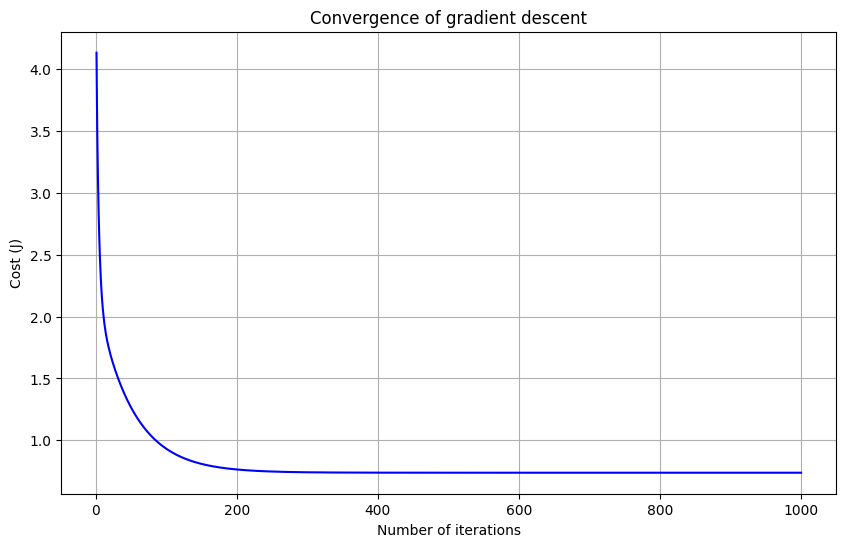

In [115]:
plt.plot(range(1, iterations + 1), cost_history, color='blue')
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)

plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title('Convergence of gradient descent')

# Show the plot
plt.show()

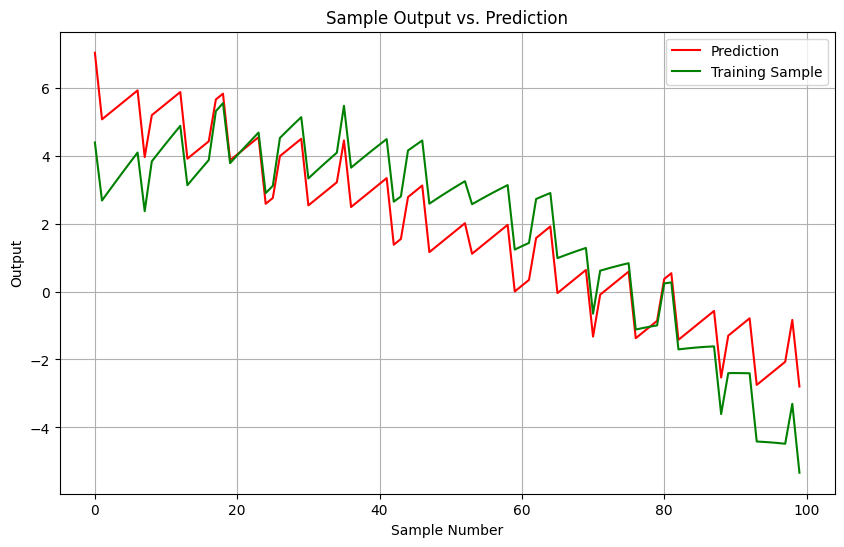

In [116]:
predictions = training.dot(theta)
arr = np.arange(m)

# Scatter plot for the training data
plt.plot(arr, predictions, color='red', label='Prediction')

# Line plot for the linear regression model
plt.plot(arr, y, color='green', label='Training Sample')

# Plot customizations
plt.rcParams["figure.figsize"] = (10, 6)
plt.grid(True)
plt.xlabel('Sample Number')
plt.ylabel('Output')
plt.title('Sample Output vs. Prediction')
plt.legend()

# Show the plot
plt.show()